# Audio and Voice Synthesis with AI (WaveNet, Jukebox)

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain how neural audio synthesis works: WaveNet's sample-by-sample autoregression and
  Jukebox's audio-token language modeling
- Represent audio digitally — synthesize a vowel-like sound from sine waves and inspect its
  waveform and spectrum
- Compute why raw-audio generation is hard (samples-per-second arithmetic)
- Run a small autoregressive generator to feel the mechanism WaveNet applies to audio

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 2, lesson 01 (autoregressive generation) and Unit 5, lesson 03 (music) — WaveNet is the same idea at 16,000 steps per second.

**Used later in:** Course 10 — Unit 5, lesson 06, which applies autoregression to a third symbolic domain: code.

---

This notebook covers practical activities from **Course 10, Unit 5**:
- Audio and voice synthesis using AI tools like WaveNet or Jukebox

---

## Introduction

**Audio and voice synthesis** models generate realistic speech and music. The full models are
far too large to train here — instead we build the two ideas they rest on: *audio as a sequence
of numbers* (hands-on below) and *autoregressive next-sample prediction* (toy model at the end).

---

## 🌍 Why this lesson exists — a cloned voice on the phone, January 2024

In January 2024, New Hampshire primary voters received a robocall in an AI-cloned voice of President Joe Biden, telling them to stay home and "save your vote". On **8 February 2024** the FCC unanimously adopted a Declaratory Ruling confirming that AI-generated voices in robocalls are "artificial" under the Telephone Consumer Protection Act — making them illegal — and it later proposed a **$6 million fine** against the consultant who commissioned the call, who was also criminally indicted in New Hampshire.

Voice synthesis went from research demo to regulated election-interference tool in about a year. The mechanism is the one below: autoregressive prediction over an audio sequence.

**What goes wrong without this:** audio is the modality where synthesis is cheapest to weaponise. A phone call has no visual channel, and voice is still treated as an identity credential by banks, call centres and families — a credential that a few minutes of recorded speech can now forge.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: orientation cell — what WaveNet and Jukebox are, before we build
# a toy autoregressive model that shares their core mechanism.
print("✅ Libraries imported!")
print("\nAudio and Voice Synthesis")
print("=" * 60)

print("\nWaveNet:")
print("  - Text-to-speech")
print("  - High-quality audio")
print("  - Autoregressive model")
print("  - Realistic voice")

print("\nJukebox:")
print("  - Music generation")
print("  - Multiple genres")
print("  - Long sequences")
print("  - OpenAI model")

print("\nApplications:")
print("  - Text-to-speech")
print("  - Voice cloning")
print("  - Music composition")
print("  - Audio synthesis")

print("\n✅ Audio synthesis concepts understood!")

✅ Libraries imported!

Audio and Voice Synthesis

WaveNet:
  - Text-to-speech
  - High-quality audio
  - Autoregressive model
  - Realistic voice

Jukebox:
  - Music generation
  - Multiple genres
  - Long sequences
  - OpenAI model

Applications:
  - Text-to-speech
  - Voice cloning
  - Music composition
  - Audio synthesis

✅ Audio synthesis concepts understood!


## Hands-On: What Audio Looks Like to a Neural Network

Sound is a **pressure wave sampled thousands of times per second** — to a model, just a very long
sequence of numbers. Human speech gets its character from **formants** (resonant frequency peaks
of the vocal tract). Below we synthesize a vowel-like tone from three sine waves at real formant
frequencies for the vowel "ah", plot what the network would "see", and compute the arithmetic
that makes raw-audio generation so much harder than text generation.

One second of audio at 16,000 Hz = 16,000 numbers — press play:


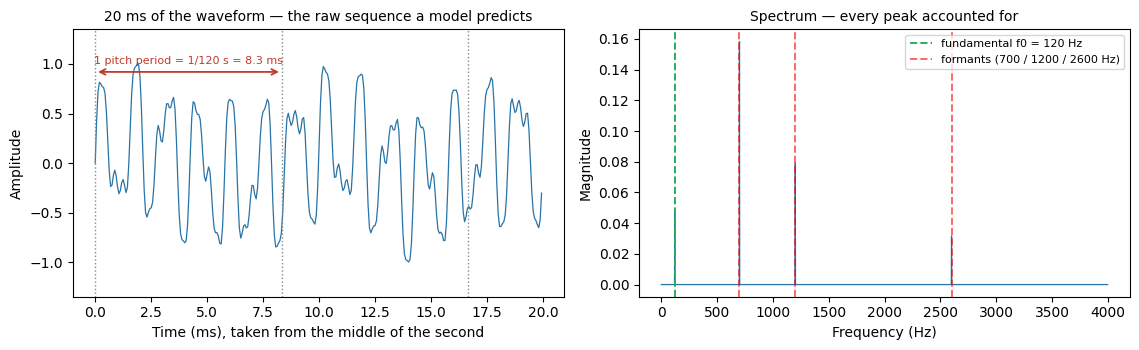

10 seconds of TEXT  ≈    150 tokens for a character model
10 seconds of AUDIO = 160,000 samples for WaveNet at 16 kHz
→ 1,066x more predictions for the same duration —
  this is why WaveNet needed dilated convolutions, and why later systems
  (Jukebox, modern TTS) first COMPRESS audio into coarser tokens, then model those.


In [2]:
# Synthesize a vowel-like sound from formant sine waves; show waveform + spectrum;
# compute the sequence-length arithmetic that makes audio generation hard.
# WHY: before understanding WaveNet, you need to see audio as the (huge) number sequence it is.
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SR = 16000                              # 16 kHz — the sample rate WaveNet used for speech
DUR = 1.0                               # one second of audio
t = np.arange(int(SR * DUR)) / SR

# ── Build an "ah"-like vowel: fundamental + three formants (typical adult values) ──
f0 = 120                                 # fundamental (vocal-fold vibration, male-ish pitch)
formants = [(700, 1.0), (1200, 0.5), (2600, 0.2)]   # (frequency Hz, relative amplitude)
wave = 0.3 * np.sin(2 * np.pi * f0 * t)              # the pitch buzz
for freq, amp in formants:
    wave += amp * np.sin(2 * np.pi * freq * t)       # add each resonance
wave *= np.hanning(len(wave))                        # fade in/out to avoid clicks
wave /= np.abs(wave).max()                           # normalize to [-1, 1]

print(f"One second of audio at {SR:,} Hz = {len(wave):,} numbers — press play:")
display(Audio(wave, rate=SR))

# ── Plot: 20 ms of waveform (what the model predicts) + frequency spectrum ─
# WHY take the window from the MIDDLE: np.hanning() fades the second in and out, so the
# first 20 ms are the fade-in and show amplitudes near zero. The middle 20 ms is where
# the envelope is ~1 and the periodic vowel shape is actually visible.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
mid = len(wave) // 2
seg = wave[mid:mid + 320]                                # 320 samples @16 kHz = 20 ms
ms  = np.arange(len(seg)) / SR * 1000
axes[0].plot(ms, seg, lw=0.9, color="#2874a6")
period_ms = 1000 / f0                                     # one vocal-fold cycle, in ms
for k in range(int(20 // period_ms) + 1):                 # mark each pitch period
    axes[0].axvline(k * period_ms, color="#7f8c8d", ls=":", lw=1)
axes[0].annotate("", xy=(period_ms, 0.92), xytext=(0, 0.92),
                 arrowprops=dict(arrowstyle="<->", color="#c0392b", lw=1.3))
axes[0].text(period_ms / 2, 1.0, f"1 pitch period = 1/{f0} s = {period_ms:.1f} ms",
             ha="center", fontsize=8, color="#c0392b")
axes[0].set_ylim(-1.35, 1.35)
axes[0].set_xlabel("Time (ms), taken from the middle of the second")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("20 ms of the waveform — the raw sequence a model predicts", fontsize=10)

spectrum = np.abs(np.fft.rfft(wave)) / len(wave)
freqs = np.fft.rfftfreq(len(wave), 1 / SR)
axes[1].plot(freqs[freqs < 4000], spectrum[freqs < 4000], lw=0.9, color="#2874a6")
# the fundamental is a peak too — mark it, or it reads as an unexplained spike
axes[1].axvline(f0, color="#27ae60", ls="--", lw=1.4, label=f"fundamental f0 = {f0} Hz")
for j, (f, _) in enumerate(formants):
    axes[1].axvline(f, color="red", ls="--", alpha=0.6, lw=1.4,
                    label="formants (700 / 1200 / 2600 Hz)" if j == 0 else None)
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Magnitude")
axes[1].set_title("Spectrum — every peak accounted for", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── The arithmetic that makes audio generation hard (computed, not asserted) ──
chars_10s   = 10 * 15                    # ~15 characters/second of read English text
samples_10s = 10 * SR
print(f"10 seconds of TEXT  ≈ {chars_10s:6,} tokens for a character model")
print(f"10 seconds of AUDIO = {samples_10s:6,} samples for WaveNet at {SR//1000} kHz")
print(f"→ {samples_10s // chars_10s:,}x more predictions for the same duration —")
print("  this is why WaveNet needed dilated convolutions, and why later systems")
print("  (Jukebox, modern TTS) first COMPRESS audio into coarser tokens, then model those.")

**Read the figure.**

*Left* — 20 milliseconds of the sound, taken from the middle of the second so the fade-in is not in
shot. The dotted lines fall every **8.3 ms** — one cycle of the vocal folds at 120 Hz — and the
stretch between two of them *nearly* repeats. Only nearly: of our three formants only 1200 Hz is a
whole-number multiple of 120, so the fine ripples do not line up cycle to cycle. Real vowels behave
the same way. This is the
whole of what a raw-audio model works with — no notes, no phonemes, just this list of numbers, 16,000
of them per second.

*Right* — the whole second seen by frequency instead of by time (the transform is taken over all
16,000 samples, not just the 20 ms on the left). Four peaks, and now all four are labelled: the green line is the 120 Hz fundamental we buzzed, and the three red lines are the
formants at 700, 1200 and 2600 Hz, with heights in the ratio 1 : 0.5 : 0.2 that we asked for. The
spectrum recovers exactly the recipe the code above wrote, which is the point — a vowel *is* a small
set of frequencies, and the enormous sample sequence on the left is an expensive way to store it.

That gap between the two panels is the number printed underneath: **1,066× more predictions** for
audio than for text over the same ten seconds. Everything WaveNet did next is an answer to it.

### The Answer WaveNet Gave — Dilated Causal Convolutions

The arithmetic above states the problem: to say anything about one second of speech a model must
see ~16,000 past samples. A normal convolution stack reaches one extra sample per layer, so it
would need ~16,000 layers. WaveNet's fix was to **double the gap between the inputs each layer
reads** — dilations of 1, 2, 4, 8, 16, ... — so the reach doubles per layer instead of growing by
one. The figure below draws that stack and then plots what the doubling buys.

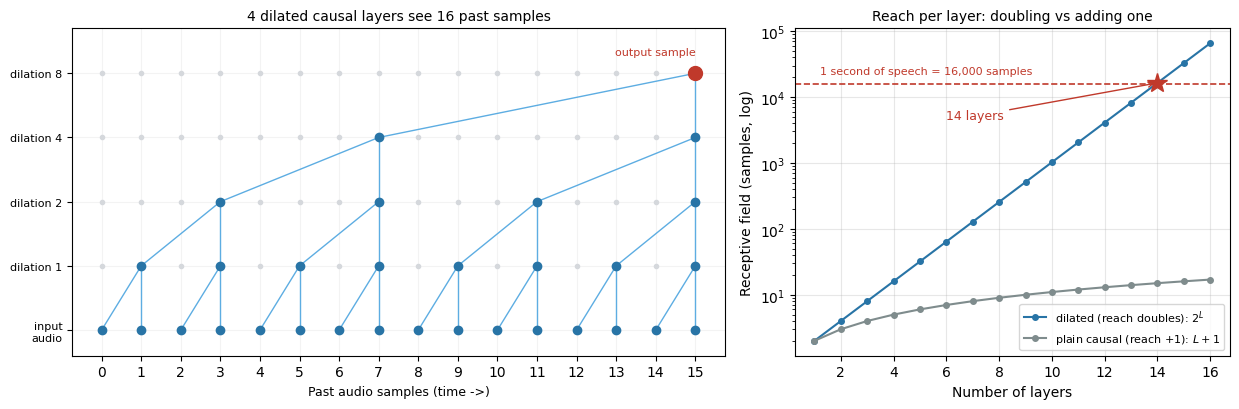

To condition on one second of 16 kHz audio (16,000 samples):
  dilated causal stack :     14 layers  (reach 2^14 = 16,384 samples)
  plain causal stack   : 15,999 layers  (reach L+1)
  -> 1,143x fewer layers for the same reach.

Receptive field, layer by layer, for the stack drawn on the left:
  after layer 1 (dilation  1):   2 samples of context
  after layer 2 (dilation  2):   4 samples of context
  after layer 3 (dilation  4):   8 samples of context
  after layer 4 (dilation  8):  16 samples of context


In [3]:
# Draw WaveNet's dilated causal convolution stack, and compute what its doubling buys.
# WHY: "dilated convolutions gave WaveNet a usable receptive field" is the central
# engineering claim of this lesson, and it is a claim about a picture.
import numpy as np
import matplotlib.pyplot as plt

DILATIONS = [1, 2, 4, 8]                      # layer l reads inputs d apart, d doubling
WIDTH = 2 ** len(DILATIONS)                   # 16 input samples cover this stack exactly

# ── Trace backwards from the output: which nodes actually feed it? ────────
active = {len(DILATIONS): {WIDTH - 1}}        # top layer: just the one output node
for layer in range(len(DILATIONS) - 1, -1, -1):
    d = DILATIONS[layer]
    active[layer] = {j - k for j in active[layer + 1] for k in (0, d) if j - k >= 0}

fig, (ax, axr) = plt.subplots(1, 2, figsize=(12.5, 4.2),
                              gridspec_kw={"width_ratios": [1.5, 1]})

# ── LEFT: the stack. Grey = a node that exists, blue = a node in the causal cone ──
for layer in range(len(DILATIONS) + 1):
    for j in range(WIDTH):
        on = j in active[layer]
        ax.plot(j, layer, "o", ms=6 if on else 3,
                color="#2874a6" if on else "#d5d8dc", zorder=3)
for layer in range(len(DILATIONS)):           # only draw the edges that reach the output
    d = DILATIONS[layer]
    for j in active[layer + 1]:
        for src in (j, j - d):
            if src >= 0:
                ax.plot([src, j], [layer, layer + 1], "-", color="#5dade2", lw=1, zorder=2)
ax.plot(WIDTH - 1, len(DILATIONS), "o", ms=10, color="#c0392b", zorder=4)
ax.text(WIDTH - 1, len(DILATIONS) + 0.28, "output sample", ha="right", fontsize=8, color="#c0392b")
ax.set_yticks(range(len(DILATIONS) + 1))
ax.set_yticklabels(["input\naudio"] + [f"dilation {d}" for d in DILATIONS], fontsize=8)
ax.set_xticks(range(WIDTH)); ax.set_xlabel("Past audio samples (time ->)", fontsize=9)
ax.set_ylim(-0.4, len(DILATIONS) + 0.7)
ax.set_title(f"{len(DILATIONS)} dilated causal layers see {WIDTH} past samples", fontsize=10)
ax.grid(alpha=0.15)

# ── RIGHT: receptive field vs depth — doubling against adding one ─────────
L = np.arange(1, 17)
rf_dilated, rf_plain = 2 ** L, L + 1
axr.plot(L, rf_dilated, "o-", color="#2874a6", ms=4, label="dilated (reach doubles): $2^L$")
axr.plot(L, rf_plain, "o-", color="#7f8c8d", ms=4, label="plain causal (reach +1): $L+1$")
axr.axhline(SR, ls="--", color="#c0392b", lw=1.2)
axr.text(1.2, SR * 1.4, f"1 second of speech = {SR:,} samples", fontsize=8, color="#c0392b")
need_dilated = int(np.ceil(np.log2(SR)))      # layers a dilated stack needs for 1 second
need_plain = SR - 1                           # layers a plain causal stack would need
axr.plot(need_dilated, 2 ** need_dilated, "*", ms=15, color="#c0392b", zorder=5)
axr.annotate(f"{need_dilated} layers", xy=(need_dilated, 2 ** need_dilated),
             xytext=(need_dilated - 8, SR / 3.5), fontsize=9, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1))
axr.set_yscale("log"); axr.set_xlabel("Number of layers"); axr.set_ylabel("Receptive field (samples, log)")
axr.set_title("Reach per layer: doubling vs adding one", fontsize=10)
axr.legend(fontsize=8, loc="lower right"); axr.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── The comparison as numbers, computed rather than asserted ──────────────
print(f"To condition on one second of {SR//1000} kHz audio ({SR:,} samples):")
print(f"  dilated causal stack : {need_dilated:>6,} layers  (reach 2^{need_dilated} = {2**need_dilated:,} samples)")
print(f"  plain causal stack   : {need_plain:>6,} layers  (reach L+1)")
print(f"  -> {need_plain / need_dilated:,.0f}x fewer layers for the same reach.")
print("\nReceptive field, layer by layer, for the stack drawn on the left:")
for layer, d in enumerate(DILATIONS, start=1):
    print(f"  after layer {layer} (dilation {d:>2}): {2**layer:>3} samples of context")


**Read the figure.**

*Left* — the stack itself. The bottom row is 16 past audio samples; each row above reads two
inputs that are 1, then 2, then 4, then 8 samples apart. Blue marks every node that actually
feeds the red output; grey nodes exist but are outside its cone. Follow the blue edges down and
you land on **all 16 inputs after only 4 layers** — the doubling gap is what lets a shallow stack
reach far back. Nothing here looks into the future: every edge goes leftward, which is the
"causal" half of the name and what makes generation one sample at a time possible.

*Right* — why that matters at 16 kHz. Doubling gives reach 2^L, adding one gives L+1, and on a log
axis the two answers separate immediately. To condition on the **one second** the red line marks,
the dilated stack needs **14 layers**; a plain causal stack of the same kernel size would need
**15,999** — the printed table works both out. That single design change is the difference between
WaveNet being trainable and being arithmetic.

**Honest limit:** 14 layers buys you the *context*, not the *speed*. WaveNet still emits one sample
per forward pass, which is why the systems named in this notebook compress audio into coarser
tokens before modelling them at all.

## 🌍 Worked Example — Autoregression, the Mechanism Inside WaveNet

WaveNet generates audio **one sample at a time**, each conditioned on the previous ones — the
same *autoregressive* recipe as a language model, just over 16,000-samples-per-second sequences
instead of characters. Jukebox does the same over compressed audio tokens.

Since a real WaveNet takes days of GPU time, we demonstrate the mechanism at trainable scale: a
**character-level model** predicting one token at a time. Every idea transfers — context window,
sampling, temperature — only the alphabet changes (characters here, audio samples in WaveNet).

In [4]:
# Train a small autoregressive model (over characters) to feel WaveNet's mechanism.
# WHY: next-token prediction is the shared engine — swap characters for audio samples
# and this becomes (a tiny) WaveNet.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# ── Vocabulary: map each character to an integer id ───────────────────────
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]


# ── Dataset: every 20-char window predicts the next character ─────────────
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# ── Training: 200 quick steps, a fresh random 256-window batch each time ──
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nOne token at a time, each conditioned on the past — swap characters for")
print("audio samples and this loop is what WaveNet runs 16,000 times per second.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notek a sea rio be to sleep o soye a ore a seaurma osagofg end tehe heartoc is to be wis ire in mylep o

One token at a time, each conditioned on the past — swap characters for
audio samples and this loop is what WaveNet runs 16,000 times per second.


Measured: 288 microseconds per generation step (median of 300 timed forward passes)


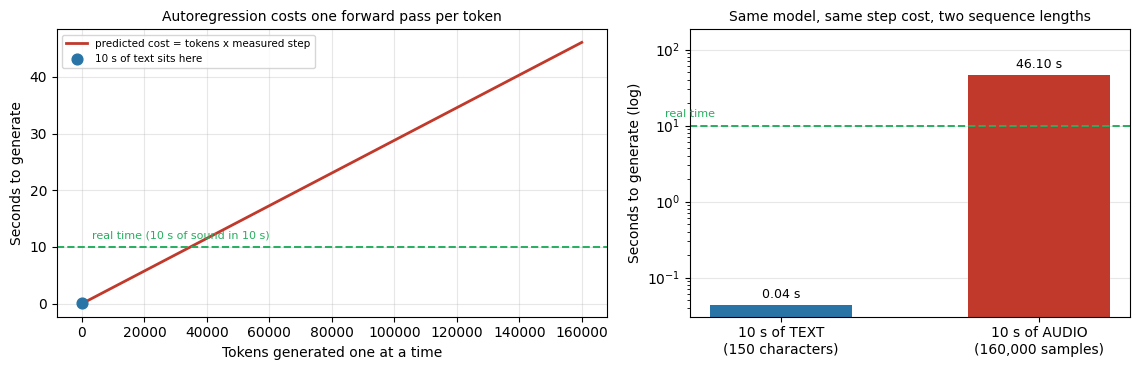


job                                 tokens     seconds   vs real time
10 s of TEXT (150 characters)          150        0.04          0.00x
10 s of AUDIO (160,000 samples)    160,000       46.10          4.61x

Honest scope: this is OUR tiny LSTM's step cost, not WaveNet's. A real WaveNet
step is far more expensive, so the audio bar moves UP, never down. The shape of
the problem — cost proportional to token count — is what transfers.


In [5]:
# The lesson's honest limit — "14 layers buys the context, not the speed" — has no
# picture yet. WHY: measure this model's ACTUAL per-step generation cost, then ask what
# that cost buys at 16 kHz. Autoregression's price is one forward pass per output token,
# and audio needs 16,000 tokens per second of sound.
import time
import matplotlib.pyplot as plt
import numpy as np

# ── Measure: time one forward pass of the generation loop, 300 times ──────
model.eval()
ctx = torch.tensor([[c2i[c] for c in "to be or not to be t"]], dtype=torch.long)
with torch.no_grad():
    for _ in range(20):                      # warm-up, so the first-call overhead is excluded
        model(ctx)
    step_times = []
    for _ in range(300):
        t0 = time.perf_counter()
        model(ctx)                           # exactly one autoregressive step
        step_times.append(time.perf_counter() - t0)
step_times = np.array(step_times)
per_step = float(np.median(step_times))
print(f"Measured: {per_step * 1e6:,.0f} microseconds per generation step "
      f"(median of {len(step_times)} timed forward passes)")

# ── Extrapolate that measured cost to the two sequence lengths ────────────
SECONDS_OF_SPEECH = 10
n_text_tokens  = SECONDS_OF_SPEECH * 15      # ~15 characters/second of read English
n_audio_tokens = SECONDS_OF_SPEECH * SR      # one token per audio sample at 16 kHz
jobs = [("10 s of TEXT\n(150 characters)", n_text_tokens, "#2874a6"),
        ("10 s of AUDIO\n(160,000 samples)", n_audio_tokens, "#c0392b")]

fig, (ax_lin, ax_bar) = plt.subplots(1, 2, figsize=(11.5, 3.8),
                                     gridspec_kw={"width_ratios": [1.25, 1]})

# LEFT: cost grows linearly with the number of tokens — no shortcut exists
n = np.arange(0, n_audio_tokens + 1, 500)
ax_lin.plot(n, n * per_step, color="#c0392b", lw=2, label="predicted cost = tokens x measured step")
ax_lin.scatter([n_text_tokens], [n_text_tokens * per_step], s=60, color="#2874a6", zorder=3,
               label="10 s of text sits here")
ax_lin.axhline(SECONDS_OF_SPEECH, ls="--", color="#27ae60", lw=1.4)
ax_lin.text(n_audio_tokens * 0.02, SECONDS_OF_SPEECH * 1.15,
            f"real time ({SECONDS_OF_SPEECH} s of sound in {SECONDS_OF_SPEECH} s)",
            fontsize=8, color="#27ae60")
ax_lin.set_xlabel("Tokens generated one at a time"); ax_lin.set_ylabel("Seconds to generate")
ax_lin.set_title("Autoregression costs one forward pass per token", fontsize=10)
ax_lin.legend(fontsize=7.5, loc="upper left"); ax_lin.grid(alpha=0.3)

# RIGHT: the same two jobs as bars on a log axis
bars = ax_bar.bar([j[0] for j in jobs], [j[1] * per_step for j in jobs],
                  color=[j[2] for j in jobs], width=0.55)
for b, (_, ntok, _) in zip(bars, jobs):
    ax_bar.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.25,
                f"{ntok * per_step:.2f} s", ha="center", fontsize=9)
ax_bar.axhline(SECONDS_OF_SPEECH, ls="--", color="#27ae60", lw=1.4)
ax_bar.text(-0.45, SECONDS_OF_SPEECH * 1.3, "real time", fontsize=8, color="#27ae60")
ax_bar.set_yscale("log"); ax_bar.set_ylabel("Seconds to generate (log)")
# headroom so the value label above the tall bar never clips, whatever this machine times
ax_bar.set_ylim(top=max(j[1] * per_step for j in jobs) * 4)
ax_bar.set_title("Same model, same step cost, two sequence lengths", fontsize=10)
ax_bar.grid(axis="y", alpha=0.3); ax_bar.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── The same numbers, printed ─────────────────────────────────────────────
print(f"\n{'job':<32}{'tokens':>10}{'seconds':>12}{'vs real time':>15}")
for label, ntok, _ in jobs:
    secs = ntok * per_step
    print(f"{label.replace(chr(10), ' '):<32}{ntok:>10,}{secs:>12.2f}"
          f"{secs / SECONDS_OF_SPEECH:>14.2f}x")
print("\nHonest scope: this is OUR tiny LSTM's step cost, not WaveNet's. A real WaveNet")
print("step is far more expensive, so the audio bar moves UP, never down. The shape of")
print("the problem — cost proportional to token count — is what transfers.")

**Read the figure.** This is the "honest limit" from the dilated-convolution section, measured.

*Left* — generation cost against tokens produced. It is a straight line through the origin, because
autoregression has exactly one price and it is one forward pass per output token. The blue dot is
ten seconds of *text*: it sits so close to the origin that you have to be told it is there. The green
dashed line is real time — ten seconds of sound produced in ten seconds — and the red line crosses
it long before it reaches the right-hand edge.

*Right* — the same two jobs as bars, on a log axis so both fit. Ten seconds of text is a rounding
error; ten seconds of audio at 16 kHz is over a thousand times more work from the *same* model with
the *same* per-step cost. The exact seconds are printed underneath, computed from the timing this
cell just measured on your machine.

Nothing about the receptive field helps here. Fourteen dilated layers let a model *see* one second
of context in a single pass; they do not let it *emit* more than one sample per pass. That is why
every system named in this notebook after WaveNet — Jukebox included — first compresses audio into
far fewer, coarser tokens, and models those instead.

## 💬 Discuss

1. Ten seconds of audio is **160,000 predictions at 16 kHz** against roughly 150 for a character model — **1,066×**. The notebook names two engineering responses to that. Which one do modern systems actually use, and why did the other lose?
2. A cloned voice defeats "I recognise your voice" as a check. What would you replace it with for a Saudi bank's call centre, at a cost the bank would actually accept? Name the trade-off your answer imposes on legitimate customers.
3. Our formant tone is three sine waves: recognisably vowel-like, unmistakably not human. What is missing — and does the missing part matter more for text-to-speech or for voice cloning?


## ⚠️ Where this breaks

**Raw-sample autoregression is impractical without architectural help.** WaveNet needed dilated convolutions to reach a usable receptive field, and every current system compresses audio into coarser tokens first — Jukebox's approach, and the open speech stacks of 2025–26 such as VibeVoice (arXiv 2508.19205) and Qwen3-TTS (arXiv 2601.15621). Do not read "autoregression works for audio" as "autoregression over samples is how it is done".

**Our stand-in is a character model.** It shares the mechanism and none of the difficulties: no phase continuity, no speaker identity, no prosody, no alignment to text. It shows you the loop; it does not show you the problem.

**Sine-wave formant synthesis is not speech synthesis.** It demonstrates what a waveform is. It teaches nothing about intelligibility, naturalness, or the perceptual metrics (MOS, intelligibility tests) by which real TTS is judged.

**Where cloning is the risk, the controls are legal and procedural, not technical.** Consent for the voice, disclosure of synthesis, and out-of-band verification. Detection alone inherits the same generalisation problem as deepfake image detection (Unit 4, notebook 02): it can only be trained on generators that already exist.


## 🔭 State of the field (2026)

Neural speech synthesis is now an open-weights problem rather than a lab-demo one, and the systems that replaced WaveNet kept its autoregressive idea while moving it off raw samples. VibeVoice generates speech by autoregressively producing latent vectors through diffusion over a highly compressed continuous speech tokenizer (Peng et al. 2025, arXiv 2508.19205), and Qwen3-TTS is a 2026 open baseline that pairs with an open recognition model to make a full speech stack (Hu et al. 2026, arXiv 2601.15621).

That is a change of *representation*, not of principle — which is exactly why this lesson starts where it does. The samples-per-second arithmetic you computed above is the constraint that forces every one of those systems to compress before it models; Jukebox's compress-then-model design is the direct ancestor of the tokenizers they use; and WaveNet's dilated causal convolutions remain the clearest single illustration of buying receptive field without buying depth. Learn the mechanism here, because the model names sitting on top of it will keep turning over — and note that the cloned-voice risk in this notebook's opening case got cheaper, not dearer, as the stack opened up.

## 📚 References & Further Reading

**Papers:**
- van den Oord et al. (2016) — [WaveNet: A Generative Model for Raw Audio](https://arxiv.org/abs/1609.03499)
- Dhariwal et al. (2020) — [Jukebox: A Generative Model for Music](https://arxiv.org/abs/2005.00341)
- Radford et al. (2019) — [GPT-2](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) *(the autoregressive recipe our toy demo shares)*

**Recent (the open speech stack named in "Where this breaks"):**
- Peng et al. (2025) — [VibeVoice Technical Report](https://arxiv.org/abs/2508.19205) *(next-token diffusion: latent vectors generated autoregressively over a highly compressed continuous speech tokenizer)*
- Hu et al. (2026) — [Qwen3-TTS Technical Report](https://arxiv.org/abs/2601.15621) *(a 2026 open text-to-speech baseline you can inspect, unlike the commercial systems named below)*
- Kong et al. (2026) — [Unified Audio Intelligence Without Regressing on Text Intelligence](https://arxiv.org/abs/2607.05196) *(Audex: understanding, recognition, synthesis and audio generation in one transformer decoder — the separate WaveNet/Jukebox pipelines folded into a single model)*

**Interactive:**
- [DeepMind's WaveNet post](https://deepmind.google/discover/blog/wavenet-a-generative-model-for-raw-audio/) — with audio samples
- [OpenAI Jukebox samples](https://openai.com/research/jukebox)

**State-of-the-Art:** ElevenLabs, Suno, and OpenAI's voice models build on these ideas with
audio-token language models plus diffusion/flow decoders.

## 📝 Summary

In this notebook, you:

- Synthesized a **vowel-like sound from formant sine waves** and inspected its waveform and
  spectrum — audio as the number sequence a model must predict
- **Computed** why raw audio is hard: ~1,000x more predictions per second than character-level
  text, which drove WaveNet's dilated convolutions and Jukebox's compress-then-model design
- Ran a small **autoregressive generator** to internalize the one-sample-at-a-time mechanism
- Learned the concepts behind **WaveNet** (autoregressive raw audio) and **Jukebox**
  (language modeling over compressed audio tokens)

**Further reading, not demonstrated here:** modern production TTS (ElevenLabs-class systems)
increasingly uses diffusion and flow-matching decoders on top of these ideas.